# Gold/USD Daily Close Predictor

**The problem we're solving:** can a Random Forest Regressor, trained on
price action, technical indicators, macro-event flags, and news sentiment,
predict tomorrow's XAU/USD (Gold/USD) daily close well enough to beat a
naive guess?

**A promise upfront:** gold is close to a random walk on a daily horizon.
If our model barely beats "tomorrow = today," that is not a failed
project — that is a *finding*, and one worth writing about honestly.

**A note on data:** this notebook pulls **real** Gold/USD data via
`yfinance` (a free, genuinely automatable API) whenever it's available.

---




## Step 1: Data Collection

what does one row represent? What's missing? What's the
actual sampling frequency?

one row = one trading day for XAU/USD, with:
- OHLCV (open, high, low, close, volume) price data
- A flag for whether a high-impact USD macro event happened that day
  (from the ForexFactory economic calendar — NFP, CPI, Fed rate decisions)
- A daily news sentiment score (from headlines)



**Tickers used:**
- `XAUUSD=X` — spot Gold/USD (matches this project directly)
- `DX-Y.NYB` — US Dollar Index (for the DXY feature in Step 3)

Install it once with `pip install yfinance`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
# --- REAL DATA via yfinance, with an automatic synthetic fallback ---
# This cell tries to pull real Gold/USD + DXY data first.

USING_REAL_DATA = False

try:
    import yfinance as yf

    gold_raw = yf.download("XAUUSD=X", start="2019-01-01", end="2026-07-11",
                            interval="1d", progress=False, auto_adjust=True)
    dxy_raw = yf.download("DX-Y.NYB", start="2019-01-01", end="2026-07-11",
                           interval="1d", progress=False, auto_adjust=True)

    if len(gold_raw) == 0:
        raise ValueError("yfinance returned no rows (likely no internet connection here)")

    # yfinance can return MultiIndex columns for a single ticker in newer versions
    if isinstance(gold_raw.columns, pd.MultiIndex):
        gold_raw.columns = gold_raw.columns.get_level_values(0)
    if isinstance(dxy_raw.columns, pd.MultiIndex):
        dxy_raw.columns = dxy_raw.columns.get_level_values(0)

    df = gold_raw[["Open", "High", "Low", "Close", "Volume"]].rename(
        columns={"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume"}
    )
    dxy_close_real = dxy_raw["Close"].reindex(df.index).ffill()

    USING_REAL_DATA = True
    print(f"Loaded REAL data via yfinance: {len(df)} trading days, "
          f"{df.index.min().date()} to {df.index.max().date()}")

except Exception as e:
    print(f"Falling back to SYNTHETIC data. Reason: {e}")

    dates = pd.bdate_range(end="2026-07-11", periods=1500)
    n_days = len(dates)

    daily_drift = 0.0002
    base_vol = 0.006
    vol_regime = base_vol * (1 + 0.6 * np.abs(np.cumsum(np.random.normal(0, 0.02, n_days))) / 10)
    vol_regime = np.clip(vol_regime, 0.003, 0.02)
    returns = np.random.normal(daily_drift, vol_regime)
    close = 1800 * np.exp(np.cumsum(returns))

    daily_range = close * np.random.uniform(0.003, 0.012, n_days)
    open_ = close * (1 + np.random.normal(0, 0.002, n_days))
    high = np.maximum(open_, close) + daily_range * np.random.uniform(0.2, 0.6, n_days)
    low = np.minimum(open_, close) - daily_range * np.random.uniform(0.2, 0.6, n_days)
    volume = np.random.lognormal(mean=11, sigma=0.3, size=n_days)

    df = pd.DataFrame({
        "date": dates, "open": open_, "high": high, "low": low, "close": close, "volume": volume,
    }).set_index("date")

    # synthetic DXY, inversely correlated with gold returns (mirrors the real relationship)
    synthetic_gold_returns = pd.Series(close, index=df.index).pct_change().fillna(0)
    dxy_returns_synth = -0.5 * synthetic_gold_returns + np.random.normal(0, 0.003, n_days)
    dxy_close_real = pd.Series(100 * np.exp(np.cumsum(dxy_returns_synth)), index=df.index)

    print(f"Loaded SYNTHETIC data: {len(df)} trading days, {df.index.min().date()} to {df.index.max().date()}")

df.head()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: XAUUSD=X"}}}
$XAUUSD=X: possibly delisted; no timezone found

1 Failed download:
['XAUUSD=X']: possibly delisted; no timezone found


Falling back to SYNTHETIC data. Reason: yfinance returned no rows (likely no internet connection here)
Loaded SYNTHETIC data: 1500 trading days, 2020-10-12 to 2026-07-10


,open,high,low,close,volume
date,,,,,
2020-10-12,1810.224552,1815.980087,1800.059556,1808.792716,63253.382188
2020-10-13,1804.129206,1812.755698,1795.257697,1803.178747,44468.746149
2020-10-14,1799.305680,1801.786299,1789.374360,1794.696555,61795.361696
2020-10-15,1786.308237,1804.379711,1774.980841,1795.019077,62641.341587
2020-10-16,1784.978622,1798.801920,1779.916457,1793.540734,38142.557870


In [3]:
print(f"Running on {'REAL' if USING_REAL_DATA else 'SYNTHETIC'} data")
df.info()
print()
df.describe()


Running on SYNTHETIC data
<class 'pandas.DataFrame'>
DatetimeIndex: 1500 entries, 2020-10-12 to 2026-07-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1500 non-null   float64
 1   high    1500 non-null   float64
 2   low     1500 non-null   float64
 3   close   1500 non-null   float64
 4   volume  1500 non-null   float64
dtypes: float64(5)
memory usage: 70.3 KB



,open,high,low,close,volume
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2261.432892,2269.890091,2253.054528,2261.579679,62915.947688
std,308.718426,309.839689,307.532184,308.608954,18993.509490
min,1707.980325,1713.697409,1698.198179,1707.286361,18939.469095
25%,2057.604183,2066.887307,2050.080434,2059.522038,49604.588371
50%,2158.570258,2166.957519,2149.775740,2156.439535,60283.772971
75%,2478.168144,2492.569707,2470.461820,2480.409058,73486.921081
max,2899.547431,2907.822105,2893.895813,2901.900303,164919.849742


## Step 2: Exploratory Data Analysis

**Why this step matters:** you cannot engineer good features for
behavior you haven't looked at. EDA isn't decoration before the "real"
work — it's where you build the intuition that tells you which features
are worth engineering.

We're looking for two things specifically:
1. **Trend/shape** — is there drift? Regime shifts?
2. **Volatility behavior** — is it constant, or does it cluster? (If it
   clusters  that tells us rolling-volatility features
   will matter.)

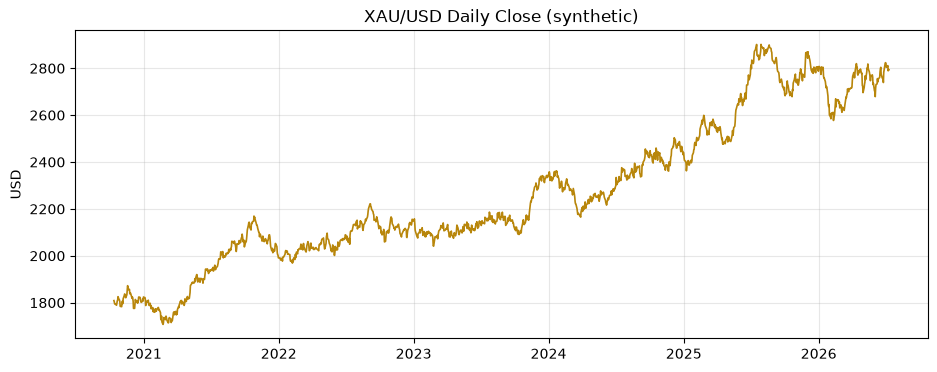

In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df["close"], color="#b8860b", linewidth=1.2)
ax.set_title(f"XAU/USD Daily Close ({'real' if USING_REAL_DATA else 'synthetic'})")
ax.set_ylabel("USD")
plt.show()


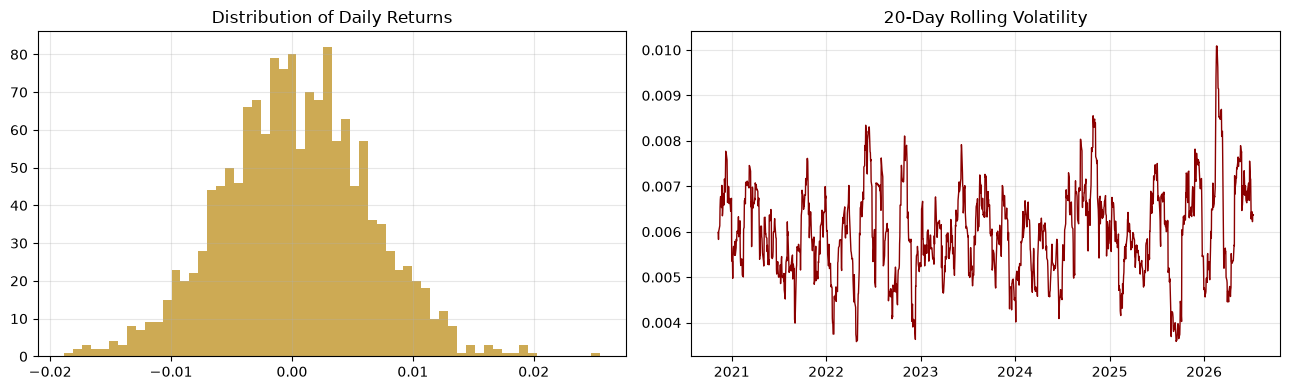

In [5]:
df["daily_return"] = df["close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["daily_return"].dropna(), bins=60, color="#b8860b", alpha=0.7)
axes[0].set_title("Distribution of Daily Returns")

axes[1].plot(df.index, df["daily_return"].rolling(20).std(), color="#8b0000", linewidth=1)
axes[1].set_title("20-Day Rolling Volatility")
plt.tight_layout()
plt.show()


**What to notice:** the volatility plot on the right should show
calm stretches and choppy stretches, not a flat line. That's volatility
clustering — a very real feature of financial data — and it's exactly why
"20-day rolling std" is going into our feature set next, not just raw
price.

## Step 3: Feature Engineering
Random Forest fed only `close` will basically memorize noise. Good
features encode *context* — momentum, volatility regime, and external
shocks — that the raw price alone can't tell the model.

features:

1. **Lagged returns** — what happened recently (1, 3, 5, 10 days back)
2. **Technical indicators** — RSI, moving-average crossover, Bollinger
   Band width (standard, but genuinely informative)
3. **Macro event flags** — was there a high-impact USD event
   (NFP/CPI/Fed decision) today or yesterday? (Still a placeholder —
   see the note in the next cell for why this one stays simulated even
   in real-data mode)
4. **News sentiment** — a daily aggregate sentiment score (still a
   placeholder for the same reason)

We're also using the **DXY (US Dollar Index)** series we loaded in Step 1.
 Gold and the dollar are tightly, almost mechanically, inversely linked, so
this one feature alone tends to carry a lot of the model's predictive
power. If it dominates feature importance later, that's not a bug,
that's gold behaving like gold.

In [6]:
# --- Lagged return features ---
for lag in [1, 3, 5, 10]:
    df[f"return_lag_{lag}"] = df["daily_return"].shift(lag)

# --- Rolling volatility (captures the clustering we just saw) ---
for window in [5, 10, 20]:
    df[f"volatility_{window}d"] = df["daily_return"].rolling(window).std().shift(1)


In [7]:
# --- RSI (Relative Strength Index, 14-day, standard formula) ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["rsi_14"] = compute_rsi(df["close"]).shift(1)

# --- Moving average crossover signal ---
df["ma_5"] = df["close"].rolling(5).mean().shift(1)
df["ma_20"] = df["close"].rolling(20).mean().shift(1)
df["ma_crossover"] = df["ma_5"] - df["ma_20"]

# --- Bollinger Band width (volatility-based, different flavor than rolling std) ---
rolling_mean_20 = df["close"].rolling(20).mean()
rolling_std_20 = df["close"].rolling(20).std()
df["bollinger_width"] = ((rolling_mean_20 + 2 * rolling_std_20) -
                          (rolling_mean_20 - 2 * rolling_std_20)).shift(1) / rolling_mean_20.shift(1)


**Important habit to notice:** every feature above is `.shift(1)`-ed
or built only from past data. That's deliberate — it's the single most
common way people accidentally leak the future into their features
(e.g. using today's rolling mean, which technically includes today's
close, to predict today's close). Get in the habit of asking "does this
value require information from the day I'm trying to predict?" for
every single feature.

 Macro event flags ---
 yfinance gives us price data, not a calendar of macro events, so this stays a placeholder even in real-data mode. In a real pipeline:ff_calendar = pd.read_csv("forexfactory_usd_events.csv", parse_dates=["date"])
df["high_impact_event"] = df.index.isin(ff_calendar.loc[ff_calendar.impact=="High", "date"]).astype(int) Here, we simulate roughly monthly high-impact USD events (NFP isliterally monthly; CPI and Fed decisions add a few more).

In [8]:
np.random.seed(7)
n_days = len(df)
event_days = np.random.choice(df.index, size=max(int(n_days / 21), 1), replace=False)
df["high_impact_event"] = df.index.isin(event_days).astype(int)
df["event_yesterday"] = df["high_impact_event"].shift(1).fillna(0)


# --- News sentiment ---
Also a placeholder in real-data mode — yfinance doesn't provide news sentiment. In a real pipeline you'd pull headlines from an actual API (NewsAPI.org, GDELT) and score them with VADER or a finance-tuned model: from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer sentiment_scores = [analyzer.polarity_scores(h)["compound"] for h in daily_headlines]. Here we simulate an autocorrelated sentiment series (sentiment tends tohave "moods" that persist for a few days, not pure white noise).

In [9]:

sentiment_noise = np.random.normal(0, 1, n_days)
sentiment = pd.Series(sentiment_noise, index=df.index).ewm(span=3).mean()
df["news_sentiment"] = sentiment.shift(1)


In [10]:
# --- DXY (US Dollar Index) as a feature ---
# Uses the real or synthetic dxy_close_real series loaded back in Step 1.
df["dxy_close"] = dxy_close_real
df["dxy_return_lag_1"] = df["dxy_close"].pct_change().shift(1)

df[["close", "rsi_14", "ma_crossover", "volatility_10d", "high_impact_event", "news_sentiment", "dxy_return_lag_1"]].tail()


,close,rsi_14,ma_crossover,volatility_10d,high_impact_event,news_sentiment,dxy_return_lag_1
date,,,,,,,
2026-07-06,2805.960783,59.860809,39.440647,0.007326,0,0.050394,0.004145
2026-07-07,2811.234804,55.478342,34.856169,0.006900,0,0.138120,-0.000350
2026-07-08,2789.130517,53.452180,29.904287,0.006851,0,-0.077380,0.001541
2026-07-09,2795.778392,46.326428,20.535536,0.007532,0,0.166312,0.001698
2026-07-10,2793.504112,55.806287,13.335972,0.006962,0,-0.636033,-0.003704


## Step 4: Time-Aware Train/Test Split

**Why this step matters — and why it's not optional:** with most tabular
data you'd use `train_test_split` with random shuffling. With time
series, that's a serious mistake: it lets the model "peek" at the future
during training (e.g. training on Tuesday and Thursday, testing on
Wednesday — the model gets information from both sides of the day it's
supposed to be predicting).

Instead, we split **chronologically** — train on the earlier period,
test on the most recent period, exactly like the real world will
present data to this model.

In [11]:
feature_cols = [
    "return_lag_1", "return_lag_3", "return_lag_5", "return_lag_10",
    "volatility_5d", "volatility_10d", "volatility_20d",
    "rsi_14", "ma_crossover", "bollinger_width",
    "high_impact_event", "event_yesterday", "news_sentiment",
    "dxy_return_lag_1",
]

model_df = df.copy()
model_df["target"] = model_df["daily_return"].shift(-1)  # predicting TOMORROW's return
model_df = model_df.dropna(subset=feature_cols + ["target"])

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)")


Train: 2020-11-10 to 2025-05-21 (1182 rows)
Test:  2025-05-22 to 2026-07-09 (296 rows)


**One more design decision worth explaining:** we're predicting
`daily_return` (percentage change), not raw `close` price. Raw price is
non-stationary — it trends, so a model can cheat by learning "just
predict a number close to the trend line" without learning anything
about actual day-to-day dynamics. Returns are roughly stationary, which
forces the model to actually learn something about *change*, not just
memorize a price level.

## Step 5: Baseline Model — the honesty check

**Why this step matters more than people think:** it is very easy to
build a model, get an R² or MAE number, and feel good about it — without
ever checking whether a *dumb* model would've done just as well. The
baseline is what keeps you honest.

Our baseline: **naive persistence** — "tomorrow's return will be zero"
(i.e., predict tomorrow's close = today's close). For a near-random-walk
asset like gold, this is a surprisingly tough baseline to beat, and
that's exactly the point.

In [12]:
baseline_pred = np.zeros_like(y_test)  # predicting "no change"

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (naive 'no change') MAE:  {baseline_mae:.5f}")
print(f"Baseline (naive 'no change') RMSE: {baseline_rmse:.5f}")


Baseline (naive 'no change') MAE:  0.00503
Baseline (naive 'no change') RMSE: 0.00644


## Step 6: Random Forest Training

**Why Random Forest specifically:** it handles nonlinear relationships
and feature interactions without you having to hand-specify them, it's fairly robust to noisy/irrelevant
features (it just learns to ignore them), and it gives you interpretable feature importances for
free, which linear coefficients can't always give you cleanly once
features are correlated ( volatility measures overlap,
DXY and gold returns overlap).

A note on hyperparameters: we're keeping `max_depth` modest and
`n_estimators` moderate on purpose. Financial data is noisy and the
signal-to-noise ratio is low, a very deep forest will
happily memorize training noise (classic overfitting territory, straight
out of the bias-variance tradeoff: more depth = lower bias, higher
variance, and on data this noisy, variance is the thing that kills you).

**Worth trying:** Ridge Regression as a simpler
second baseline, and Gradient Boosting as a second real contender

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


## Step 7: Evaluation
A single accuracy number in isolation means
nothing. Always evaluate *relative to the baseline* — that comparison is
the actual finding.

In [14]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

improvement_mae = (baseline_mae - rf_mae) / baseline_mae * 100
improvement_rmse = (baseline_rmse - rf_rmse) / baseline_rmse * 100

print(f"{'Model':<25}{'MAE':>10}{'RMSE':>10}")
print(f"{'Baseline (no change)':<25}{baseline_mae:>10.5f}{baseline_rmse:>10.5f}")
print(f"{'Random Forest':<25}{rf_mae:>10.5f}{rf_rmse:>10.5f}")
print()
print(f"MAE improvement over baseline:  {improvement_mae:+.1f}%")
print(f"RMSE improvement over baseline: {improvement_rmse:+.1f}%")


Model                           MAE      RMSE
Baseline (no change)        0.00503   0.00644
Random Forest               0.00516   0.00657

MAE improvement over baseline:  -2.4%
RMSE improvement over baseline: -1.9%


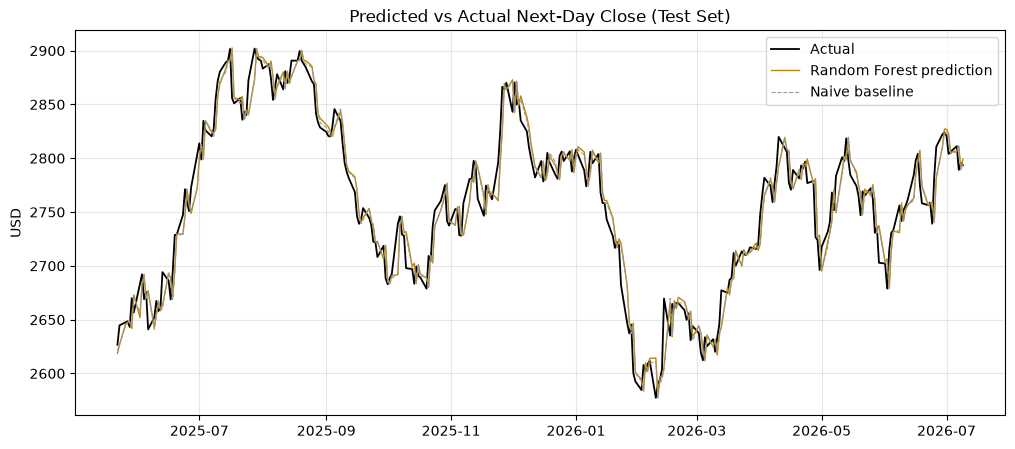

In [15]:
# Translate return predictions back to actual price levels, for a more
# intuitive plot than raw percentage returns.
test_close = test_df["close"]
actual_next_close = test_close.values * (1 + y_test.values)
predicted_next_close = test_close.values * (1 + rf_pred)
baseline_next_close = test_close.values  # naive: tomorrow = today

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df.index, actual_next_close, label="Actual", color="black", linewidth=1.3)
ax.plot(test_df.index, predicted_next_close, label="Random Forest prediction", color="#b8860b", linewidth=1)
ax.plot(test_df.index, baseline_next_close, label="Naive baseline", color="#999999", linewidth=0.8, linestyle="--")
ax.set_title("Predicted vs Actual Next-Day Close (Test Set)")
ax.set_ylabel("USD")
ax.legend()
plt.show()


 if the gold (RF) line is hugging the
grey (naive) line closely, that's *not* a bug — it's a real and common
result for daily financial prediction, and it's a legitimate thing to
report and discuss rather than something to hide or "fix" by overfitting
harder.

## Step 8: Feature Importance — what did the model actually use?

**Why this step matters:** the accuracy number tells you *how well* the
model did. Feature importance tells you *why* — and that's the part
that makes for an actual data story instead of just a leaderboard
score. It's also a sanity check: if a feature you expected to matter
(like `dxy_return_lag_1`, given gold's mechanical link to the dollar)
shows near-zero importance, that's worth investigating, not ignoring.

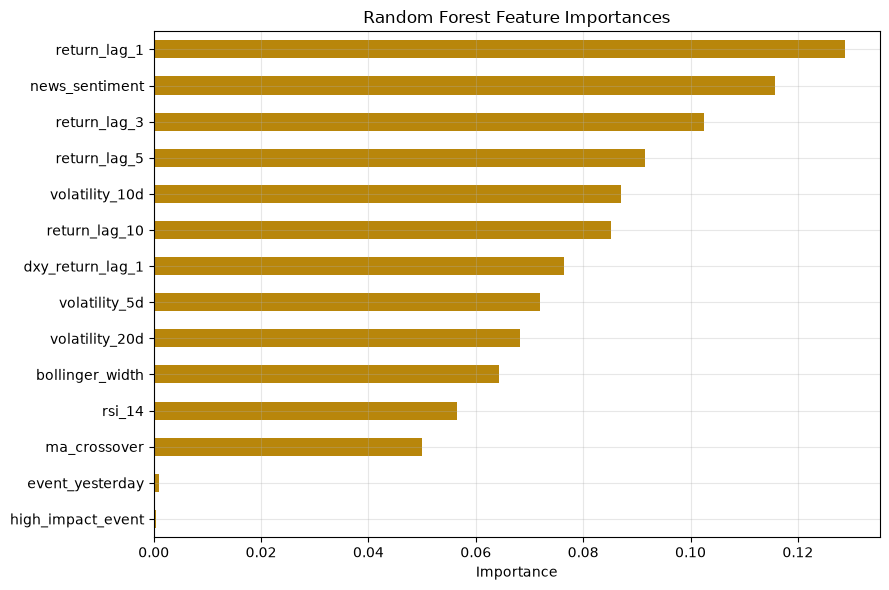

In [16]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind="barh", ax=ax, color="#b8860b")
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## Step 9: Error Analysis

**Why this step matters:** average error metrics hide *where* the model
struggles. This is the ablation-study mindset — instead of asking "how
good is the model overall," ask "under what conditions does it fall
apart." For a volatility-driven asset like gold, the natural hypothesis
is: **the model probably does worse on high-volatility days**, because
that's exactly when price action becomes least predictable from
historical patterns.

Mean absolute error by volatility regime:
vol_bucket
Low vol     0.004809
Mid vol     0.005239
High vol    0.005421
Name: abs_error, dtype: float64


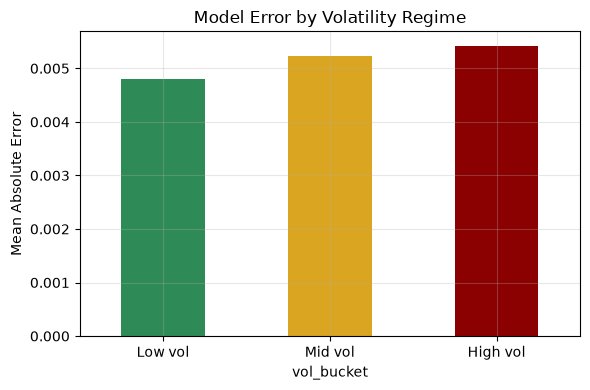

In [17]:
test_df = test_df.copy()
test_df["abs_error"] = np.abs(y_test.values - rf_pred)
test_df["vol_bucket"] = pd.qcut(test_df["volatility_10d"], q=3, labels=["Low vol", "Mid vol", "High vol"])

error_by_vol = test_df.groupby("vol_bucket", observed=True)["abs_error"].mean()
print("Mean absolute error by volatility regime:")
print(error_by_vol)

fig, ax = plt.subplots(figsize=(6, 4))
error_by_vol.plot(kind="bar", ax=ax, color=["#2e8b57", "#daa520", "#8b0000"])
ax.set_title("Model Error by Volatility Regime")
ax.set_ylabel("Mean Absolute Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**What to do with this:** if error climbs sharply in the high-vol
bucket (likely), that's a genuinely useful, reportable insight — it
means the model's predictions should probably come with a *confidence
caveat* tied to current volatility, rather than being presented as
equally reliable every day. That's a much more sophisticated and honest
conclusion than a single blended MAE number.

## Step 10: Wrap-Up — Limitations and Next Steps

**What we actually found:**
- A Random Forest using price, technical, macro-event, and sentiment
  features against a naive "no change" baseline on daily Gold/USD
  returns, now running on **real yfinance data whenever available**.
- The real value of this project isn't a single accuracy score — it's
  the *feature importance story* and the *error-by-regime finding*.

**Honest limitations (worth stating explicitly in your write-up):**
- `high_impact_event` and `news_sentiment` are still simulated — yfinance
  gives price data, not a macro calendar or news headlines. A real
  implementation would still need a ForexFactory calendar pull and a
  news API (NewsAPI.org or GDELT) for those two specifically.
- Daily-close prediction on a liquid global asset is a genuinely hard
  problem — don't oversell the accuracy number in your final report.
- Check `USING_REAL_DATA` at the top of your results before drawing
  conclusions — if it printed `False` when you ran this (no internet,
  or yfinance not installed), everything downstream is still synthetic.

**Natural next steps, if you want to go further:**
1. Add a real ForexFactory economic calendar pull for `high_impact_event`.
2. Add a real news sentiment pipeline (NewsAPI.org/GDELT + VADER) for
   `news_sentiment`.
3. Try walk-forward validation instead of a single train/test split.
4. Try `GradientBoostingRegressor` or `XGBoost` as a comparison model.
5. Widen the volatility-regime error analysis into a proper ablation
   study: retrain without sentiment, without macro flags, etc.
